## CUSTODIAN STOCK PRICE PREDICTION

In [1]:
## to change the name across the code
## ctrl + h will open the tab the fill the new name in replace
## to change the name across the entire code so you dont have to click enter everytime
## ctrl + shift + h

import pandas as pd

custodian=pd.read_csv('../stock_data/custodian.csv') ## so it can be small letter. This is cool.
custodian=custodian.drop(columns=['high_price','low_price'])
custodian.rename(columns={'trade_date':'date'},inplace=True)
custodian['date']=pd.to_datetime(custodian['date'])
custodian['month']=custodian['date'].dt.month
custodian['quarter']=custodian['date'].dt.quarter
custodian['year']=custodian['date'].dt.year

custodian

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,76395,CUSTODIAN,2018-06-25,5.26,5.26,427626,2026-04-08T03:05:19.028214+00:00,6,2,2018
1,76489,CUSTODIAN,2018-06-26,5.18,5.18,1824160,2026-04-08T03:05:21.361472+00:00,6,2,2018
2,76583,CUSTODIAN,2018-06-27,5.02,5.02,774293,2026-04-08T03:05:23.730487+00:00,6,2,2018
3,76677,CUSTODIAN,2018-06-28,5.02,5.02,51164,2026-04-08T03:05:26.342484+00:00,6,2,2018
4,76771,CUSTODIAN,2018-06-29,5.12,5.12,174118,2026-04-08T03:05:28.786725+00:00,6,2,2018
...,...,...,...,...,...,...,...,...,...,...
1903,298046,CUSTODIAN,2026-07-13,65.90,65.90,129577,2026-07-13T15:10:02.995074+00:00,7,3,2026
1904,298484,CUSTODIAN,2026-07-14,65.90,65.90,463879,2026-07-14T15:10:03.094441+00:00,7,3,2026
1905,298922,CUSTODIAN,2026-07-15,69.00,69.00,783641,2026-07-15T15:10:03.078609+00:00,7,3,2026
1906,299360,CUSTODIAN,2026-07-16,69.00,69.00,242133,2026-07-16T15:10:03.113936+00:00,7,3,2026


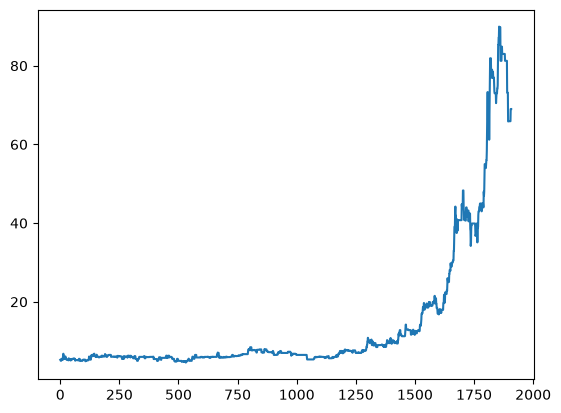

In [2]:
import matplotlib.pyplot as plt

plt.plot(custodian['close_price'])
plt.show()

In [4]:
custodian_end_month_df = (
    custodian
    .sort_values("date")
    .groupby(custodian["date"].dt.to_period("M"))
    .tail(1)
    .reset_index(drop=True)
)

custodian_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,76771,CUSTODIAN,2018-06-29,5.12,5.12,174118,2026-04-08T03:05:28.786725+00:00,6,2,2018
1,78851,CUSTODIAN,2018-07-31,5.45,5.45,118070,2026-04-08T03:06:33.766078+00:00,7,3,2018
2,80751,CUSTODIAN,2018-08-31,5.17,5.17,11208,2026-04-08T03:07:34.108038+00:00,8,3,2018
3,82654,CUSTODIAN,2018-09-28,5.18,5.18,456722,2026-04-08T03:08:29.283021+00:00,9,3,2018
4,84796,CUSTODIAN,2018-10-31,5.00,5.00,66996,2026-04-08T03:09:32.658485+00:00,10,4,2018
...,...,...,...,...,...,...,...,...,...,...
93,35282,CUSTODIAN,2026-03-31,75.00,75.00,1281351,2026-03-31T15:00:02.085058+00:00,3,1,2026
94,281109,CUSTODIAN,2026-04-30,87.15,87.15,1581086,2026-04-30T15:00:02.170664+00:00,4,2,2026
95,284175,CUSTODIAN,2026-05-29,83.00,83.00,569400,2026-05-29T15:00:02.455558+00:00,5,2,2026
96,294104,CUSTODIAN,2026-06-30,65.85,65.85,1398713,2026-06-30T15:10:03.08168+00:00,6,2,2026


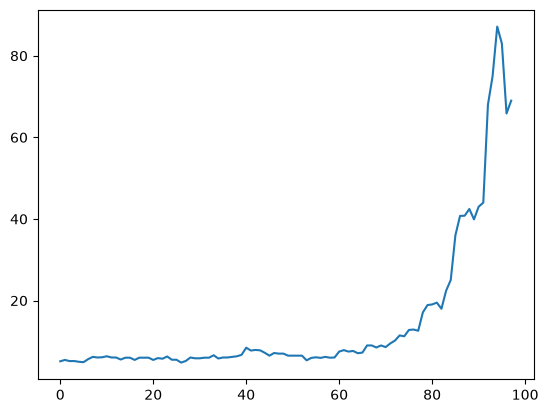

In [5]:
plt.plot(custodian_end_month_df['close_price'])
plt.show()

In [6]:
custodian_end_month_df['returns']=custodian_end_month_df['close_price'].pct_change()*100
custodian_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year,returns
0,76771,CUSTODIAN,2018-06-29,5.12,5.12,174118,2026-04-08T03:05:28.786725+00:00,6,2,2018,NaN
1,78851,CUSTODIAN,2018-07-31,5.45,5.45,118070,2026-04-08T03:06:33.766078+00:00,7,3,2018,6.445312
2,80751,CUSTODIAN,2018-08-31,5.17,5.17,11208,2026-04-08T03:07:34.108038+00:00,8,3,2018,-5.137615
3,82654,CUSTODIAN,2018-09-28,5.18,5.18,456722,2026-04-08T03:08:29.283021+00:00,9,3,2018,0.193424
4,84796,CUSTODIAN,2018-10-31,5.00,5.00,66996,2026-04-08T03:09:32.658485+00:00,10,4,2018,-3.474903
...,...,...,...,...,...,...,...,...,...,...,...
93,35282,CUSTODIAN,2026-03-31,75.00,75.00,1281351,2026-03-31T15:00:02.085058+00:00,3,1,2026,10.294118
94,281109,CUSTODIAN,2026-04-30,87.15,87.15,1581086,2026-04-30T15:00:02.170664+00:00,4,2,2026,16.200000
95,284175,CUSTODIAN,2026-05-29,83.00,83.00,569400,2026-05-29T15:00:02.455558+00:00,5,2,2026,-4.761905
96,294104,CUSTODIAN,2026-06-30,65.85,65.85,1398713,2026-06-30T15:10:03.08168+00:00,6,2,2026,-20.662651


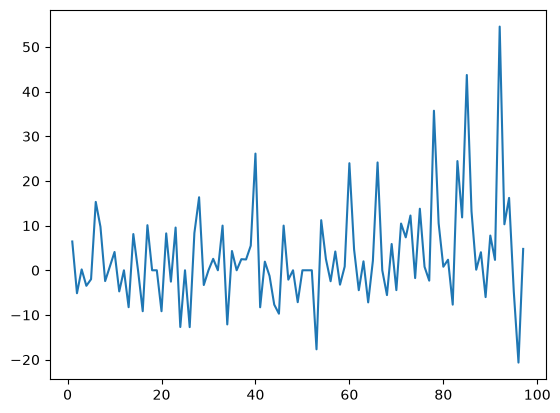

In [7]:
plt.plot(custodian_end_month_df['returns'])
plt.show()

In [8]:
## Test stationarity

from statsmodels.tsa.stattools import adfuller

result = adfuller(custodian_end_month_df['returns'].dropna())
print(result)
pvalue = result[1]
if pvalue < 0.05:
    print('stationary')
else:
    print('not stationary')

(np.float64(-0.9293677275551283), np.float64(0.7781474477587416), 8, 88, {'1%': np.float64(-3.506944401824286), '5%': np.float64(-2.894989819214876), '10%': np.float64(-2.584614550619835)}, np.float64(646.9551762604126))
not stationary


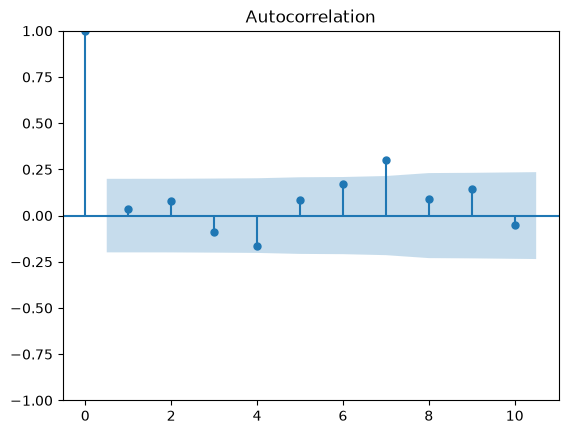

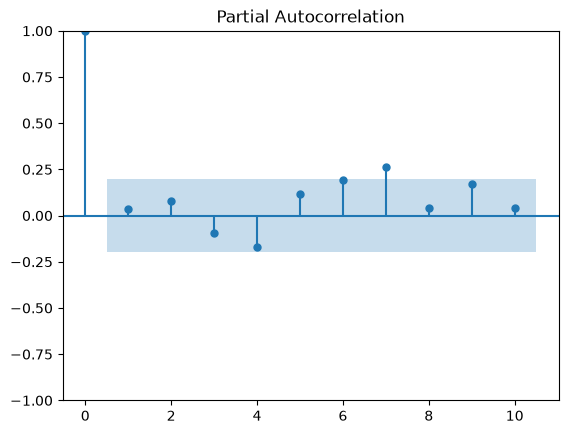

In [9]:
# Plotting the autocorrelation function and the partial autocorrelation function
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(custodian_end_month_df['returns'].dropna(), lags=10)
plot_pacf(custodian_end_month_df['returns'].dropna(), lags=10)
plt.show()

In [10]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=custodian_end_month_df['close_price'][:-10]
test=custodian_end_month_df['close_price'][-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -13.154554556420255]
[0, 0, 0, 0, 0, 1, -8.140091500685662]
[0, 0, 0, 0, 0, 2, -5.785450389301864]
[0, 0, 0, 0, 1, 0, -5.766192761234966]
[0, 0, 0, 0, 1, 1, -4.393939763579319]
[0, 0, 0, 0, 1, 2, -3.5638649326892082]
[0, 0, 0, 0, 2, 0, -3.032596886309136]
[0, 0, 0, 0, 2, 1, -2.630958787538672]
[0, 0, 0, 0, 2, 2, -2.3449020842465824]
[0, 0, 0, 1, 0, 0, -6.315732039690413]
[0, 0, 0, 1, 0, 1, -5.059941942187096]
[0, 0, 0, 1, 0, 2, -4.677497500219884]
[0, 0, 0, 1, 1, 0, -3.9513380110993515]
[0, 0, 0, 1, 1, 1, -3.6730856479758076]
[0, 0, 0, 1, 1, 2, -3.5491634053920214]
[0, 0, 0, 1, 2, 0, -2.455634588981933]
[0, 0, 0, 1, 2, 1, -2.4658918564948134]
[0, 0, 0, 1, 2, 2, -2.303244463821587]
[0, 0, 0, 2, 0, 0, -5.1375861457618]
[0, 0, 0, 2, 0, 1, -4.852934188102347]
[0, 0, 0, 2, 0, 2, -4.708173613257204]
[0, 0, 0, 2, 1, 0, -3.633093154923185]
[0, 0, 0, 2, 1, 1, -3.6399837309241585]
[0, 0, 0, 2, 1, 2, -5.766189371430475]
[0, 0, 0, 2, 2, 0, -2.4659500890829165]
[0, 0, 0, 2, 2, 1,

In [11]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
0,0,0,0,0,0,0,-13.154555
27,0,0,1,0,0,0,-12.646368
54,0,0,2,0,0,0,-12.092524
55,0,0,2,0,0,1,-8.204242
1,0,0,0,0,0,1,-8.140092
...,...,...,...,...,...,...,...
658,2,2,0,1,0,1,0.502696
657,2,2,0,1,0,0,0.503963
668,2,2,0,2,0,2,0.504280
649,2,2,0,0,0,1,0.505815


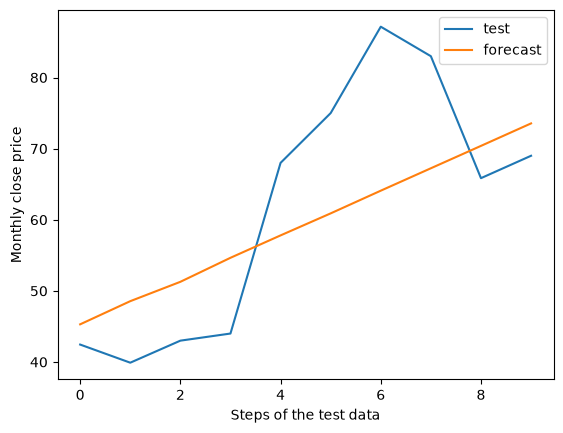

r2_score:  0.5205239367824084
rmse:  11.786282456340926
description:  count    98.000000
mean     14.398673
std      18.190035
min       4.800000
25%       6.000000
50%       6.500000
75%      10.987500
max      87.150000
Name: close_price, dtype: float64


In [14]:
# Fitting a SARIMAX model with our best model 
# order=(2,0,1), seasonal_order=(1,2,1,10)

import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

y_train=custodian_end_month_df['close_price'][:-10]
y_test=custodian_end_month_df['close_price'][-10:]

# scaler=StandardScaler()
# exog_train_scaled=scaler.fit_transform(X_full[:-10])
# exog_test_scaled=scaler.transform(X_full[-10:])

mod = SARIMAX(
y_train,
order=(2,2,0), 
seasonal_order=(0,0,0,12),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10)

plt.plot(list(y_test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Monthly close price')
plt.legend(['test', 'forecast'])
plt.show()
print('r2_score: ',r2_score(y_test, fcst))
print('rmse: ', np.sqrt(mean_squared_error(y_test,fcst)))
print('description: ', custodian_end_month_df.close_price.describe())

Its not capturing the variations properly. Lets try the returns

In [15]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=custodian_end_month_df['returns'].dropna()[:-10]
test=custodian_end_month_df['returns'].dropna()[-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -0.13555205532497716]
[0, 0, 0, 0, 0, 1, -0.19732521303048034]
[0, 0, 0, 0, 0, 2, -0.28065638321973174]
[0, 0, 0, 0, 1, 0, -1.2569585921406317]
[0, 0, 0, 0, 1, 1, -0.7836723739356162]
[0, 0, 0, 0, 1, 2, -0.6846425088196693]
[0, 0, 0, 0, 2, 0, -2.8199890106827765]
[0, 0, 0, 0, 2, 1, -1.579788285256333]
[0, 0, 0, 0, 2, 2, -1.585772004512735]
[0, 0, 0, 1, 0, 0, -0.2779207535822219]
[0, 0, 0, 1, 0, 1, -0.2745430619496274]
[0, 0, 0, 1, 0, 2, -0.2713824889884475]
[0, 0, 0, 1, 1, 0, -0.9868310640445144]
[0, 0, 0, 1, 1, 1, -0.6576768218379423]
[0, 0, 0, 1, 1, 2, -0.6578578226881036]
[0, 0, 0, 1, 2, 0, -2.159027741961052]
[0, 0, 0, 1, 2, 1, -1.5264148387354624]
[0, 0, 0, 1, 2, 2, -1.4832654098024904]
[0, 0, 0, 2, 0, 0, -0.2730391596966293]
[0, 0, 0, 2, 0, 1, -0.27031638164372374]
[0, 0, 0, 2, 0, 2, -0.21697619899396559]
[0, 0, 0, 2, 1, 0, -0.9104903341134154]
[0, 0, 0, 2, 1, 1, -0.6577054358136083]
[0, 0, 0, 2, 1, 2, -0.6618668117458439]
[0, 0, 0, 2, 2, 0, -2.146781760375256]

In [16]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
168,0,2,0,0,2,0,-167.312685
177,0,2,0,1,2,0,-157.386197
186,0,2,0,2,2,0,-116.024908
179,0,2,0,1,2,2,-108.021794
169,0,2,0,0,2,1,-106.859880
...,...,...,...,...,...,...,...
108,0,1,1,0,0,0,-0.013402
432,1,2,1,0,0,0,-0.004140
324,1,1,0,0,0,0,-0.003946
513,2,0,1,0,0,0,-0.002987


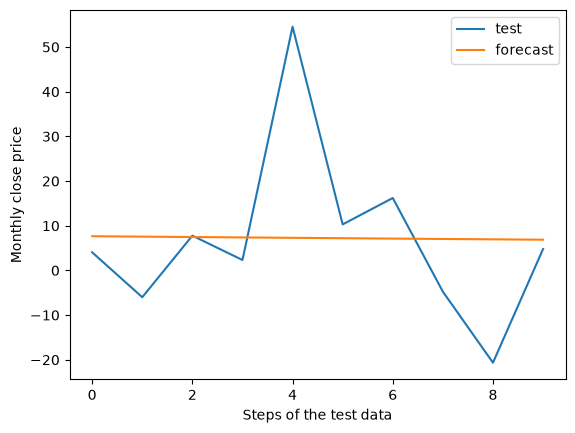

r2_score:  0.003217000568169981
rmse:  18.58370249116093
description:  count    97.000000
mean      3.291938
std      11.444408
min     -20.662651
25%      -2.542373
50%       0.793651
75%       8.256881
max      54.545455
Name: returns, dtype: float64


In [17]:
# Fitting a SARIMAX model with our best model 
# order=(2,0,1), seasonal_order=(1,2,1,10)

import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

y_train=custodian_end_month_df['returns'].dropna()[:-10]
y_test=custodian_end_month_df['returns'].dropna()[-10:]

# scaler=StandardScaler()
# exog_train_scaled=scaler.fit_transform(X_full[:-10])
# exog_test_scaled=scaler.transform(X_full[-10:])

mod = SARIMAX(
y_train,
order=(1,0,1), 
seasonal_order=(0,0,0,12),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10)

plt.plot(list(y_test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Monthly close price')
plt.legend(['test', 'forecast'])
plt.show()
print('r2_score: ',r2_score(y_test, fcst))
print('rmse: ', np.sqrt(mean_squared_error(y_test,fcst)))
print('description: ', custodian_end_month_df.returns.dropna().describe())

Very horrible. We will work with close_price
